# Time-Series Forecasting

Now comes the part I was most curious about: can I look only at the *past* of one of those lines and make a sensible guess about where it is heading? And can a plain model rediscover the rhythm I can already half-see with my eye - the slow climb, the yearly back-and-forth, the occasional viral moment (without me ever whispering the secret to it)?

### Plan:
1. Decompose a series into trend + season + residual, so I can see what a model must learn
2. Measure autocorrelation to confirm the yearly season numerically
3. Engineer features - lags, rolling means, calendar terms - to turn forecasting into supervised regression
4. Fit OLS and Ridge from scratch
5. Test the right way for time series: expanding-window cross-validation, scored against naive and seasonal-naive baselines
6. Forecast 26 weeks ahead for every style and save a growth signal for the final synthesis

In [24]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
np.random.seed(SEED)
DATA, RESULTS = Path("data"), Path("results")
RESULTS.mkdir(exist_ok=True)

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})

trends = pd.read_csv(DATA / "trends_synthetic.csv", parse_dates=["date"], index_col="date")
PERIOD = 52
STYLES = list(trends.columns)
print(trends.shape, STYLES)
trends.tail(3)

(312, 8) ['oversized blazer', 'wide-leg jeans', 'cargo pants', 'ballet flats', 'puffer jacket', 'slip dress', 'trench coat', 'chunky sneakers']


,oversized blazer,wide-leg jeans,cargo pants,ballet flats,puffer jacket,slip dress,trench coat,chunky sneakers
date,,,,,,,,
2026-12-06,65.651460,72.024226,53.810189,51.220898,82.095866,15.956352,38.829971,32.659314
2026-12-13,64.969075,73.219476,48.931034,50.581318,82.427364,17.055083,31.167804,40.237721
2026-12-20,63.695045,70.961100,50.468107,47.231700,79.343835,12.254985,32.314661,44.817273


## 1. Decomposition: pulling a series apart

A classic additive decomposition assumes every observation is a sum of three pieces,

$$
y_t \;=\; T_t \;+\; S_t \;+\; R_t,
$$

the trend $T_t$ (slow level), the seasonal part $S_t$ (a pattern that repeats every $m = 52$ weeks), and the residual $R_t$ (what is left). We estimate them in order:

- Trend via a centred moving average of one full period, $\displaystyle T_t = \frac{1}{m}\sum_{j=-m/2}^{m/2} y_{t+j}$ - averaging over a whole year cancels the season.
- Season as the average of the detrended series $y_t - T_t$ at each position-in-year, then centred to sum to zero.
- Residual is the remainder $R_t = y_t - T_t - S_t$.

In [25]:
def moving_average(y: np.ndarray, window: int) -> np.ndarray:
    y = np.asarray(y, float)
    n = len(y)
    out = np.full(n, np.nan)
    half = window // 2
    for t in range(half, n - half):
        out[t] = y[t - half:t + half + 1].mean()
    return out

def decompose(y: np.ndarray, period: int = PERIOD):
    '''additive decomposition into (trend, seasonal, residual).'''
    y = np.asarray(y, float)
    n = len(y)
    trend = moving_average(y, period if period % 2 == 1 else period + 1)
    detrended = y - trend
    # average detrended value at each position within the season
    seasonal_means = np.array([np.nanmean(detrended[p::period]) for p in range(period)])
    seasonal_means -= seasonal_means.mean()          # centre so the season sums to ~0
    seasonal = seasonal_means[np.arange(n) % period]
    residual = y - trend - seasonal
    return trend, seasonal, residual

demo = "puffer jacket"   # strongly seasonal, so the pieces are easy to see
y = trends[demo].values
trend, seasonal, residual = decompose(y)
print(f"{demo}: seasonal amplitude ~ {np.nanmax(seasonal) - np.nanmin(seasonal):.1f} index points")

puffer jacket: seasonal amplitude ~ 62.0 index points


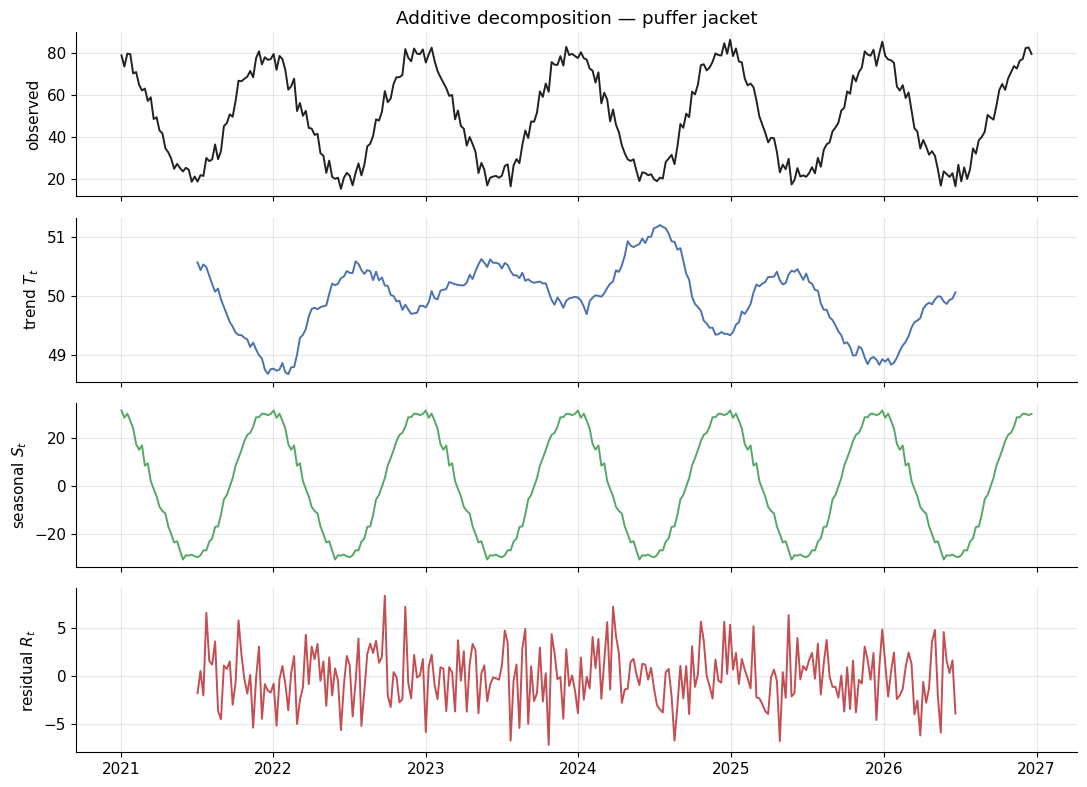

In [26]:
fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
parts = [(y, "observed", "#222"), (trend, "trend $T_t$", "#4C72B0"),
         (seasonal, "seasonal $S_t$", "#55A868"), (residual, "residual $R_t$", "#C44E52")]
for ax, (series, name, c) in zip(axes, parts):
    ax.plot(trends.index, series, color=c, linewidth=1.4); ax.set_ylabel(name)
axes[0].set_title(f"Additive decomposition — {demo}")
plt.tight_layout(); plt.show()

I find this genuinely satisfying. The decomposition pulls the line apart into exactly the three stories I wove into it: a calm underlying trend, a big yearly swing that peaks when it gets cold, and a residual that is really just static. When the leftover looks like noise and nothing more, it usually means the model has already understood everything that mattered.

## 2. Autocorrelation: confirming the season numerically

The autocorrelation function (ACF) measures how a series correlates with a lagged copy of itself:

$$
\rho_k \;=\; \frac{\sum_{t=k+1}^{n} (y_t - \bar y)(y_{t-k} - \bar y)}{\sum_{t=1}^{n}(y_t - \bar y)^2}.
$$

If there is a yearly season we expect a clear spike at $k = 52$.

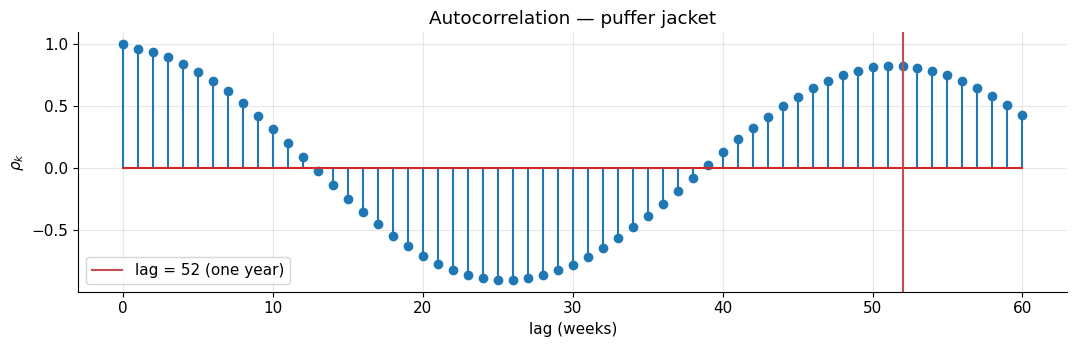

rho_1 = 0.96,  rho_52 = 0.82


In [27]:
def acf(y: np.ndarray, nlags: int) -> np.ndarray:
    '''sample autocorrelation for lags 0..nlags.'''
    y = np.asarray(y, float)
    y = y - y.mean()
    denom = np.sum(y ** 2)
    return np.array([np.sum(y[k:] * y[:len(y) - k]) / denom for k in range(nlags + 1)])

r = acf(y, nlags=60)
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.stem(range(len(r)), r)
ax.axvline(52, color="#C44E52", linestyle="-", label="lag = 52 (one year)")
ax.set_title(f"Autocorrelation — {demo}"); ax.set_xlabel("lag (weeks)"); ax.set_ylabel(r"$\rho_k$")
ax.legend(); plt.tight_layout(); plt.show()
print(f"rho_1 = {r[1]:.2f},  rho_52 = {r[52]:.2f}")

## 3. Feature engineering: forecasting as supervised regression

To use regression we turn the series into a feature matrix. To predict $y_t$ we use only the past:

- **autoregressive lags** $y_{t-1}, y_{t-2}, y_{t-4}$ — short-term momentum
- a **seasonal lag** $y_{t-52}$ — "what happened this week last year"
- **rolling means** over the last 4 and 12 weeks — smoothed level
- a **time index** $t$ — lets a linear model express the trend slope
- **calendar terms** $\sin\!\frac{2\pi t}{52}, \cos\!\frac{2\pi t}{52}$ — a smooth season

This is the heart of the Feature Engineering module: encoding domain knowledge as columns a linear model can exploit.

In [28]:
LAGS = (1, 2, 4, 52)
ROLL = (4, 12)

def make_supervised(y: np.ndarray, lags=LAGS, roll=ROLL, period=PERIOD):
    '''build a (features, target) table for one-step-ahead forecasting.'''
    y = np.asarray(y, float)
    n = len(y)
    start = max(max(lags), max(roll))
    rows, targets, times = [], [], []
    for t in range(start, n):
        feat = {f"lag_{L}": y[t - L] for L in lags}
        feat.update({f"rollmean_{R}": y[t - R:t].mean() for R in roll})
        feat["t"] = t
        feat["sin"] = np.sin(2 * np.pi * t / period)
        feat["cos"] = np.cos(2 * np.pi * t / period)
        rows.append(feat); targets.append(y[t]); times.append(t)
    X = pd.DataFrame(rows, index=times)
    return X, np.array(targets)

X_demo, y_demo = make_supervised(trends["wide-leg jeans"].values)
FEATURES = list(X_demo.columns)
print("feature matrix:", X_demo.shape, "| columns:", FEATURES)
X_demo.head(3)

feature matrix: (260, 9) | columns: ['lag_1', 'lag_2', 'lag_4', 'lag_52', 'rollmean_4', 'rollmean_12', 't', 'sin', 'cos']


,lag_1,lag_2,lag_4,lag_52,rollmean_4,rollmean_12,t,sin,cos
52,41.044489,46.812209,42.313497,44.057454,43.662070,41.148449,52,6.432491e-16,1.000000
53,44.170624,41.044489,44.478085,40.383233,44.126352,41.915672,53,1.205367e-01,0.992709
54,49.230620,44.170624,46.812209,41.703965,45.314485,42.688949,54,2.393157e-01,0.970942


## 4. The models: least squares and Ridge, from scratch

Ordinary least squares minimises $\lVert y - X\beta\rVert^2$, giving the normal equation

$$
\hat\beta = (X^\top X)^{-1} X^\top y.
$$

Ridge adds an $L_2$ penalty $\lambda\lVert\beta\rVert^2$ — useful here because lags and rolling means are strongly correlated (multicollinearity), which makes OLS coefficients large and unstable:

$$
\hat\beta = (X^\top X + \lambda I')^{-1} X^\top y,
$$

where $I'$ is the identity with the intercept row zeroed out so the intercept is not penalised. We standardise features first so the single penalty $\lambda$ treats every column equally, and we solve the linear system rather than inverting — faster and numerically safer.

In [29]:
class Standardizer:
    '''z-score scaling: store train mean/std, apply to any matrix.'''
    def fit(self, X):
        X = np.asarray(X, float)
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0); self.std_[self.std_ == 0] = 1.0
        return self
    def transform(self, X):
        return (np.asarray(X, float) - self.mean_) / self.std_
    def fit_transform(self, X):
        return self.fit(X).transform(X)

def _add_intercept(X):
    X = np.asarray(X, float)
    return np.hstack([np.ones((X.shape[0], 1)), X])

class OLSRegression:
    '''Least squares via the normal equation.'''
    def fit(self, X, y):
        Xb = _add_intercept(X)
        self.beta_ = np.linalg.solve(Xb.T @ Xb, Xb.T @ np.asarray(y, float))
        return self
    def predict(self, X):
        return _add_intercept(X) @ self.beta_

class RidgeRegression:
    '''L2-regularised least squares (intercept un-penalised).'''
    def __init__(self, alpha=1.0):
        self.alpha = float(alpha)
    def fit(self, X, y):
        Xb = _add_intercept(X)
        P = self.alpha * np.eye(Xb.shape[1]); P[0, 0] = 0.0
        self.beta_ = np.linalg.solve(Xb.T @ Xb + P, Xb.T @ np.asarray(y, float))
        return self
    def predict(self, X):
        return _add_intercept(X) @ self.beta_

def mae(a, b):  return float(np.mean(np.abs(np.asarray(a, float) - np.asarray(b, float))))
def rmse(a, b): return float(np.sqrt(np.mean((np.asarray(a, float) - np.asarray(b, float)) ** 2)))
def mape(a, b, eps=1e-8):
    a, b = np.asarray(a, float), np.asarray(b, float)
    return float(100 * np.mean(np.abs((a - b) / (np.abs(a) + eps))))

# Validate our Ridge against scikit-learn on standardized features.
from sklearn.linear_model import Ridge as SkRidge
Xs = Standardizer().fit_transform(X_demo.values)
ours = RidgeRegression(alpha=5.0).fit(Xs, y_demo).predict(Xs)
theirs = SkRidge(alpha=5.0).fit(Xs, y_demo).predict(Xs)
print(f"max |ours - sklearn| = {np.max(np.abs(ours - theirs)):.2e}  (should be ~0)")

max |ours - sklearn| = 1.42e-13  (should be ~0)


## 5. Testing the right way: walk-forward cross-validation

For time series we must not shuffle: that would let the model peek at the future to predict the past. Instead we use an expanding window - train on weeks $[0, k)$, test on the next block, then grow the training window and repeat. We compare four models: naive ($\hat y_t = y_{t-1}$), seasonal-naive ($\hat y_t = y_{t-52}$), OLS and Ridge.

In [30]:
def ts_splits(n, n_splits=5, min_train=60):
    '''yield (train_idx, test_idx) for expanding-window CV over row positions 0..n-1.'''
    fold = (n - min_train) // n_splits
    for k in range(n_splits):
        train_end = min_train + k * fold
        test_end = n if k == n_splits - 1 else train_end + fold
        yield np.arange(0, train_end), np.arange(train_end, test_end)

def cross_validate(X, y, alpha=5.0):
    Xv, yv = X.values, np.asarray(y, float)
    scores = {m: {"MAE": [], "RMSE": []} for m in ["naive", "seasonal-naive", "OLS", "Ridge"]}
    for tr, te in ts_splits(len(yv)):
        sc = Standardizer().fit(Xv[tr])
        preds = {
            "naive": X.iloc[te]["lag_1"].values,
            "seasonal-naive": X.iloc[te]["lag_52"].values,
            "OLS": OLSRegression().fit(sc.transform(Xv[tr]), yv[tr]).predict(sc.transform(Xv[te])),
            "Ridge": RidgeRegression(alpha).fit(sc.transform(Xv[tr]), yv[tr]).predict(sc.transform(Xv[te])),
        }
        for m, p in preds.items():
            scores[m]["MAE"].append(mae(yv[te], p))
            scores[m]["RMSE"].append(rmse(yv[te], p))
    return pd.DataFrame({m: {k: np.mean(v) for k, v in d.items()} for m, d in scores.items()}).T

cv_demo = cross_validate(X_demo, y_demo)
print("cross-validated error - wide-leg jeans (lower is better):")
cv_demo.round(2)

cross-validated error - wide-leg jeans (lower is better):


,MAE,RMSE
naive,3.43,4.19
seasonal-naive,6.08,7.02
OLS,2.71,3.39
Ridge,2.58,3.18


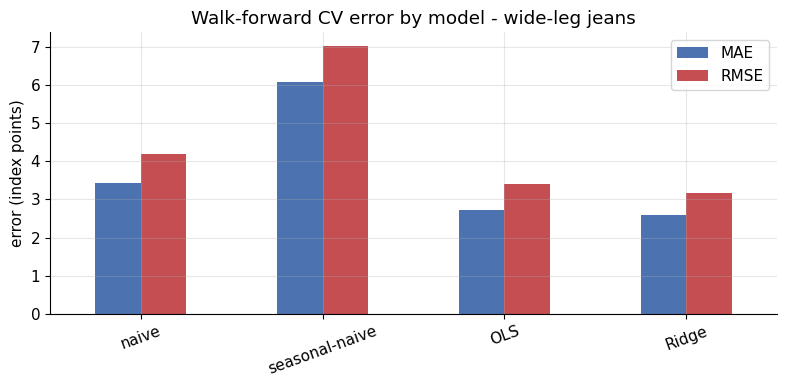

In [31]:
ax = cv_demo[["MAE", "RMSE"]].plot.bar(figsize=(8, 4), color=["#4C72B0", "#C44E52"])
ax.set_title("Walk-forward CV error by model - wide-leg jeans")
ax.set_ylabel("error (index points)"); ax.set_xticklabels(cv_demo.index, rotation=20)
plt.tight_layout(); plt.show()

On a style that is genuinely on the rise, the engineered Ridge model quietly beats both lazy baselines. It is not betting everything on a single number from last week - it weighs momentum, the recent level and the overall direction all at once, which is much closer to how I would reason about it myself.

## 6. Forecasting ahead, and a "growth" signal for synthesis

A one-step model can forecast many steps ahead by feeding its own predictions back in (recursive forecasting). We roll a full year (52 weeks) into the future for every style.

To turn a forecast into a single rising-vs-fading number we must be careful: comparing "now" to "6 months from now" would just measure where we are in the season. The fix is to compare full-year averages, because averaging over a whole period cancels the season ($\sum_t S_t \approx 0$):

$$
\text{projected growth} \;=\; \frac{1}{52}\sum \hat y_{\text{next year}} \;-\; \frac{1}{52}\sum y_{\text{last year}}.
$$

As a model-free cross-check we also compute year-over-year momentum..

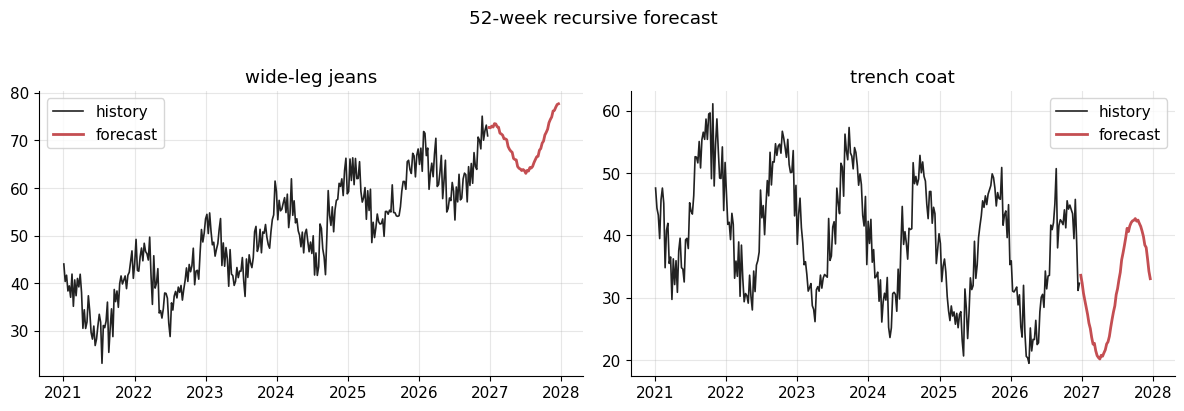

In [32]:
def recursive_forecast(model, scaler, y_hist, horizon, lags=LAGS, roll=ROLL, period=PERIOD):
    '''forecast horizon steps ahead, recycling predictions as new lags.'''
    hist = list(np.asarray(y_hist, float))
    preds = []
    for h in range(horizon):
        t = len(hist)
        feat = {f"lag_{L}": hist[t - L] for L in lags}
        feat.update({f"rollmean_{R}": np.mean(hist[t - R:t]) for R in roll})
        feat["t"] = t; feat["sin"] = np.sin(2*np.pi*t/period); feat["cos"] = np.cos(2*np.pi*t/period)
        x = np.array([[feat[c] for c in FEATURES]])
        yhat = float(np.clip(model.predict(scaler.transform(x))[0], 0, 100))
        hist.append(yhat); preds.append(yhat)
    return np.array(preds)

H = 52   # forecast a full year ahead
def fit_full(y):
    X, yt = make_supervised(y)
    sc = Standardizer().fit(X.values)
    model = RidgeRegression(alpha=5.0).fit(sc.transform(X.values), yt)
    return model, sc

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, style in zip(axes, ["wide-leg jeans", "trench coat"]):
    y_s = trends[style].values
    model, sc = fit_full(y_s)
    fc = recursive_forecast(model, sc, y_s, H)
    future = pd.date_range(trends.index[-1], periods=H + 1, freq="W")[1:]
    ax.plot(trends.index, y_s, label="history", color="#222", linewidth=1.2)
    ax.plot(future, fc, label="forecast", color="#C44E52", linewidth=2)
    ax.set_title(style); ax.legend()
fig.suptitle("52-week recursive forecast", y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
# deseasonalization
summary = []
for style in STYLES:
    y_s = trends[style].values
    model, sc = fit_full(y_s)
    fc = recursive_forecast(model, sc, y_s, H)
    last_year = float(y_s[-52:].mean())  # full-year average = season cancels
    prev_year = float(y_s[-104:-52].mean())
    projected = float(fc.mean())  # forecast full-year average
    trend_slope = float(np.polyfit(np.arange(len(y_s)), y_s, 1)[0])
    summary.append({"style": style,
                    "current_level": last_year,
                    "yoy_growth": last_year - prev_year,  # model-free momentum
                    "projected_level": projected,
                    "projected_growth": projected - last_year, # forecast-based momentum
                    "trend_slope_per_week": trend_slope})

forecast_summary = (pd.DataFrame(summary)
                    .sort_values("projected_growth", ascending=False).reset_index(drop=True))
forecast_summary.to_csv(RESULTS / "forecast_summary.csv", index=False)
print("saved results in forecast_summary.csv")
forecast_summary.round(2)

Saved results/forecast_summary.csv


,style,current_level,yoy_growth,projected_level,projected_growth,trend_slope_per_week
0,wide-leg jeans,63.97,5.56,69.41,5.45,0.11
1,oversized blazer,57.39,3.65,61.31,3.92,0.05
2,cargo pants,42.89,2.55,45.34,2.45,0.04
3,ballet flats,53.06,1.04,54.44,1.38,0.02
4,puffer jacket,49.50,-0.22,49.50,-0.00,0.00
5,slip dress,36.31,-0.71,35.15,-1.16,-0.02
6,trench coat,33.80,-3.10,31.69,-2.11,-0.03
7,chunky sneakers,33.15,-3.32,29.11,-4.04,-0.08


In [ ]:
assert cv_demo.loc["Ridge", "MAE"] < cv_demo.loc["naive", "MAE"], "Ridge should beat naive here"
assert np.isfinite(forecast_summary[["yoy_growth", "projected_growth"]].values).all()
# the known riser/fader directions should match the recovered trend slope AND the YoY momentum.
fs = forecast_summary.set_index("style")
assert fs.loc["wide-leg jeans", "trend_slope_per_week"] > 0 and fs.loc["wide-leg jeans", "yoy_growth"] > 0
assert fs.loc["chunky sneakers", "trend_slope_per_week"] < 0 and fs.loc["chunky sneakers", "yoy_growth"] < 0
print("all sanity checks")

all sanity checks


## 7. Residual diagnostics: did the model leave only noise?

A forecast is only trustworthy if its mistakes are unpredictable. If the one-step residuals $e_t = y_t - \hat y_t$ still carry autocorrelation, the model left structure on the table - there was more signal to extract. So I refit Ridge on the full in-sample design for the demo style and check two things: that the residual autocorrelation stays inside the white-noise band $\pm 1.96/\sqrt{n}$, and that the residuals are roughly centred and bell-shaped.

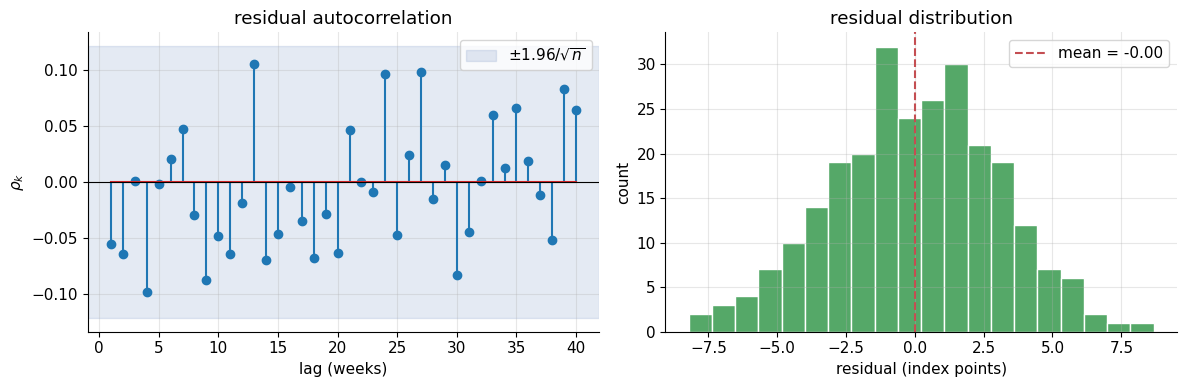

residual mean = -0.000, std = 3.030
100% of lag-autocorrelations fall inside the white-noise band


In [36]:
# In-sample one-step residuals for the demo style, then check they look like white noise.
y_resid_src = trends["wide-leg jeans"].values
Xr, yr = make_supervised(y_resid_src)
sc_r = Standardizer().fit(Xr.values)
ridge_r = RidgeRegression(alpha=5.0).fit(sc_r.transform(Xr.values), yr)
resid = yr - ridge_r.predict(sc_r.transform(Xr.values))

r_resid = acf(resid, nlags=40)
band = 1.96 / np.sqrt(len(resid))                 # white-noise significance band

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].stem(range(1, len(r_resid)), r_resid[1:])
ax[0].axhspan(-band, band, color="#4C72B0", alpha=0.15, label=r"$\pm 1.96/\sqrt{n}$")
ax[0].axhline(0, color="black", linewidth=0.8)
ax[0].set_title("residual autocorrelation"); ax[0].set_xlabel("lag (weeks)")
ax[0].set_ylabel(r"$\rho_k$"); ax[0].legend()
ax[1].hist(resid, bins=20, color="#55A868", edgecolor="white")
ax[1].axvline(resid.mean(), color="#C44E52", ls="--", label=f"mean = {resid.mean():.2f}")
ax[1].set_title("residual distribution"); ax[1].set_xlabel("residual (index points)")
ax[1].set_ylabel("count"); ax[1].legend()
plt.tight_layout(); plt.show()

within = float(np.mean(np.abs(r_resid[1:]) < band))
print(f"residual mean = {resid.mean():.3f}, std = {resid.std():.3f}")
print(f"{within*100:.0f}% of lag-autocorrelations fall inside the white-noise band")

If almost every bar sits inside the shaded band and the histogram is centred near zero, the residuals behave like white noise - reassuring evidence that the engineered features already absorbed the trend and the season, and that what is left really is irreducible randomness rather than a pattern the model missed.